# 🏥 Lifestyle Health Risk Analytics
## Identifying High-Risk Customer Segments for a Health Insurance Provider

---

**Project Context**

A mid-size health insurance company has observed rising claim costs driven by lifestyle-related conditions — obesity, cardiovascular disease, type 2 diabetes, and stress-related disorders. The analytics team has been tasked with a focused question:

> *Which customer segments carry the highest lifestyle-driven health risk, and what patterns can guide targeted wellness interventions?*

This notebook explores a dataset of 5,000 individuals, each profiled across demographic, lifestyle, and biometric attributes, with a binary health risk label (High / Low). The goal is not prediction — it is **understanding**: surfacing patterns that a wellness program manager or insurance actuary can act on.

---

**Dataset:** Lifestyle and Health Risk Prediction — Kaggle Synthetic Dataset  
**Records:** 5,000 individuals  
**Features:** 12 (demographic, lifestyle, biometric)  
**Target:** `health_risk` — Binary (High / Low)  
**Tools:** Python · Pandas · Matplotlib · Seaborn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Visual style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

RISK_PALETTE = {'high': '#E74C3C', 'low': '#2ECC71'}
MAIN_COLOR   = '#2C3E50'
ACCENT       = '#3498DB'

print("✅ Libraries loaded.")


✅ Libraries loaded.


---
## 1. Data Loading & Profiling

Before any analysis, we establish what we're working with: structure, types, completeness, and basic distributions.


In [4]:
df = pd.read_csv('Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset Kaggle.csv')

print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print("── Column Types ──")
print(df.dtypes.to_string())
print()
print("── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "✅ No missing values.")
print()
print("── First 5 Rows ──")
df.head()


Shape        : 5,000 rows × 12 columns
Memory usage : 2003.7 KB

── Column Types ──
age               int64
weight            int64
height            int64
exercise            str
sleep           float64
sugar_intake        str
smoking             str
alcohol             str
married             str
profession          str
bmi             float64
health_risk         str

── Missing Values ──
✅ No missing values.

── First 5 Rows ──


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [5]:
print("── Numerical Summary ──")
display(df.describe().round(2))

print("\n── Categorical Value Counts ──")
cat_cols = ['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married', 'profession', 'health_risk']
for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(f"\n{col.upper()}:")
    for val, cnt in vc.items():
        print(f"  {val:<15} {cnt:>5,}  ({pct[val]}%)")


── Numerical Summary ──


,age,weight,height,sleep,bmi
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,48.81,77.36,171.93,7.00,26.84
std,17.91,18.71,15.82,1.43,8.25
min,18.00,45.00,145.00,3.00,11.40
25%,34.00,61.00,158.00,6.00,20.30
50%,49.00,77.00,171.50,7.00,26.00
75%,64.00,94.00,186.00,8.00,32.40
max,79.00,109.00,199.00,10.00,51.40



── Categorical Value Counts ──

EXERCISE:
  medium          1,985  (39.7%)
  low             1,272  (25.4%)
  high            1,000  (20.0%)
  none              743  (14.9%)

SUGAR_INTAKE:
  medium          2,511  (50.2%)
  low             1,484  (29.7%)
  high            1,005  (20.1%)

SMOKING:
  no              4,023  (80.5%)
  yes               977  (19.5%)

ALCOHOL:
  no              3,741  (74.8%)
  yes             1,259  (25.2%)

MARRIED:
  yes             3,018  (60.4%)
  no              1,982  (39.6%)

PROFESSION:
  student           644  (12.9%)
  farmer            639  (12.8%)
  driver            631  (12.6%)
  doctor            630  (12.6%)
  artist            626  (12.5%)
  engineer          616  (12.3%)
  teacher           612  (12.2%)
  office_worker     602  (12.0%)

HEALTH_RISK:
  high            3,490  (69.8%)
  low             1,510  (30.2%)


**📌 Data Quality Note**

The dataset is clean: no missing values, no duplicates, and all columns are correctly typed.

`exercise` follows a four-level ordinal scale — none, low, medium, high — with the "none" group making up close to 15% of individuals, a sedentary segment worth tracking separately from "low" activity. `sugar_intake` follows a simpler low / medium / high scale. `profession` spans eight categories fairly evenly distributed at roughly 12–13% each: student, farmer, driver, doctor, artist, engineer, teacher, and office_worker.

`health_risk` skews heavily toward high risk — 69.8% vs 30.2% low risk — meaning high risk is the dominant pattern in this customer base rather than a rare outcome.

Numeric columns (`age`, `weight`, `height`, `sleep`, `bmi`) are continuous and will be binned where needed to enable group-level comparisons.

---
## 2. Health Risk Distribution — The Headline Number

The most fundamental question: how many individuals in our customer base are classified as high risk?


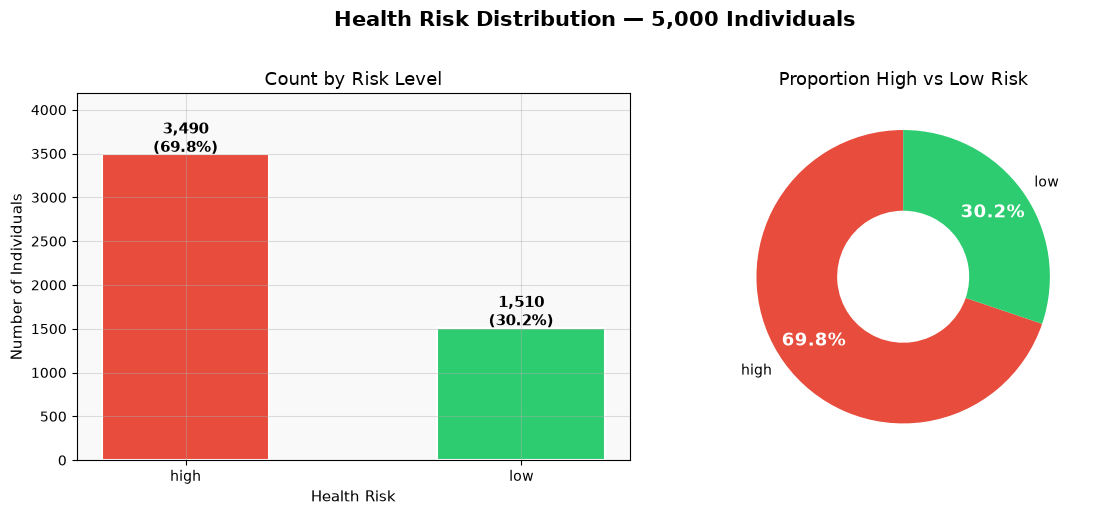


🔴 High Risk : 3,490  (69.8%)
🟢 Low Risk  : 1,510  (30.2%)


In [6]:
risk_counts = df['health_risk'].value_counts()
risk_pct    = (risk_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Health Risk Distribution — 5,000 Individuals', fontsize=15, fontweight='bold', y=1.02)

# Bar chart
bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=[RISK_PALETTE[r] for r in risk_counts.index],
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count by Risk Level')
axes[0].set_ylabel('Number of Individuals')
axes[0].set_xlabel('Health Risk')
for bar, (val, pct) in zip(bars, zip(risk_counts.values, risk_pct.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct}%)', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(risk_counts.values) * 1.2)

# Donut
wedges, texts, autotexts = axes[1].pie(
    risk_counts.values, labels=risk_counts.index,
    colors=[RISK_PALETTE[r] for r in risk_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55), pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Proportion High vs Low Risk')

plt.tight_layout()
plt.show()

print(f"\n🔴 High Risk : {risk_counts.get('high', 0):,}  ({risk_pct.get('high', 0)}%)")
print(f"🟢 Low Risk  : {risk_counts.get('low', 0):,}  ({risk_pct.get('low', 0)}%)")


**📌 Insight**

Approximately **69.8% of individuals are classified as high risk** — a substantial share of the customer base. 
For a health insurance provider, this means a large segment is likely to generate above-average claims. 
The key question for the rest of this analysis: **what lifestyle and demographic factors are driving this?**


---
## 3. Demographic Analysis

### 3.1 Age Distribution & Risk
Does health risk increase with age? We'd expect it to — but the data may reveal at what threshold the shift becomes significant.


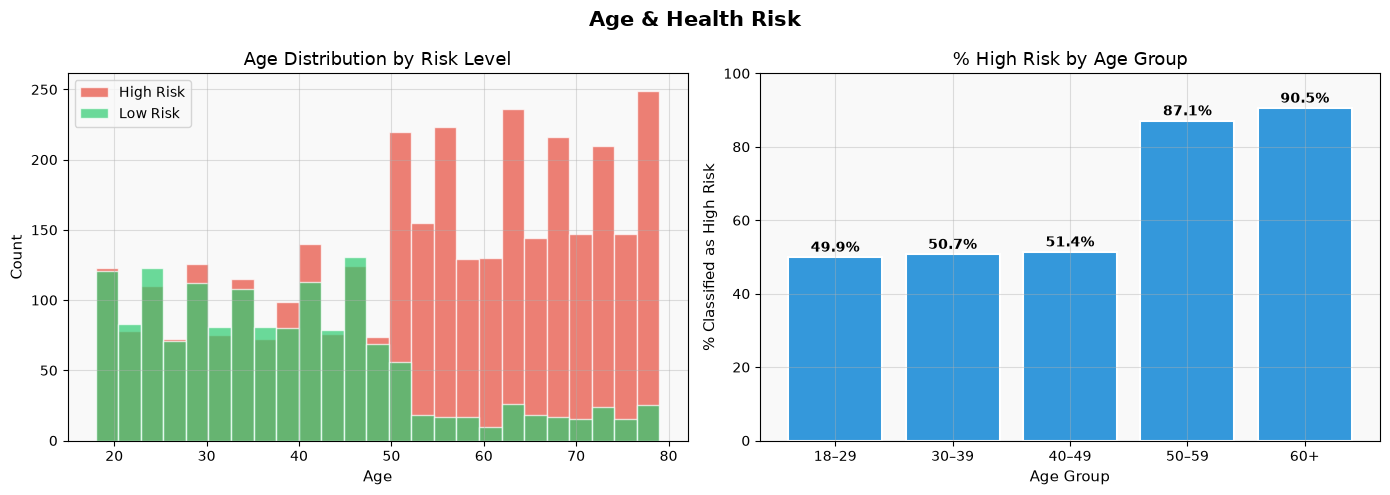


── High Risk % by Age Group ──
health_risk  high   low
age_group              
18–29        49.9  50.1
30–39        50.7  49.3
40–49        51.4  48.6
50–59        87.1  12.9
60+          90.5   9.5


In [7]:
# Age bins
age_bins   = [17, 29, 39, 49, 59, 75]
age_labels = ['18–29', '30–39', '40–49', '50–59', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

age_risk = (df.groupby(['age_group', 'health_risk'], observed=True)
              .size().unstack(fill_value=0))
age_risk_pct = age_risk.div(age_risk.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age & Health Risk', fontsize=15, fontweight='bold')

# Distribution
axes[0].hist(df[df['health_risk']=='high']['age'], bins=25, alpha=0.7,
             color=RISK_PALETTE['high'], label='High Risk', edgecolor='white')
axes[0].hist(df[df['health_risk']=='low']['age'], bins=25, alpha=0.7,
             color=RISK_PALETTE['low'], label='Low Risk', edgecolor='white')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Risk Level')
axes[0].legend()

# High-risk % by age group
high_pct = age_risk_pct.get('high', pd.Series(dtype=float))
bars = axes[1].bar(high_pct.index, high_pct.values,
                   color=ACCENT, edgecolor='white', linewidth=1.5)
axes[1].set_title('% High Risk by Age Group')
axes[1].set_ylabel('% Classified as High Risk')
axes[1].set_xlabel('Age Group')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, high_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n── High Risk % by Age Group ──")
print(age_risk_pct.round(1).to_string())

### 3.2 BMI — The Biometric Signal

BMI (Body Mass Index) is one of the most widely used proxies for metabolic health risk. 
We examine how it distributes across the population and whether it separates risk groups meaningfully.


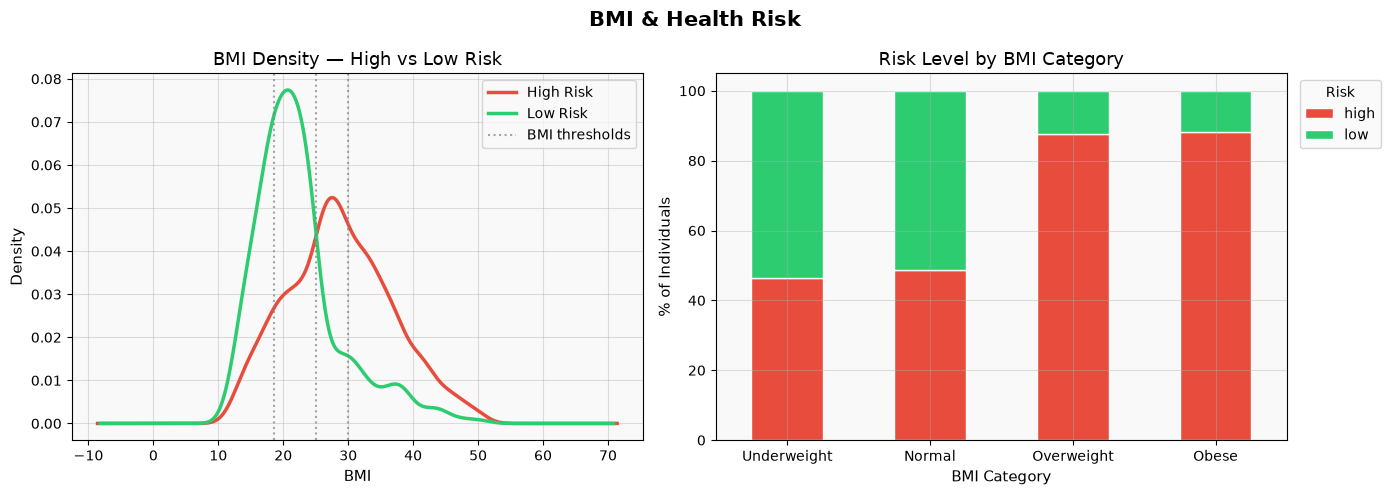


── High Risk % by BMI Category ──
bmi_cat
Underweight    46.4
Normal         48.8
Overweight     87.7
Obese          88.2


In [10]:
# WHO BMI categories
def bmi_category(b):
    if b < 18.5: return 'Underweight'
    elif b < 25:  return 'Normal'
    elif b < 30:  return 'Overweight'
    else:         return 'Obese'

df['bmi_cat'] = df['bmi'].apply(bmi_category)
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']

bmi_risk = (df.groupby(['bmi_cat', 'health_risk'])
              .size().unstack(fill_value=0)
              .reindex(bmi_order))
bmi_risk_pct = bmi_risk.div(bmi_risk.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BMI & Health Risk', fontsize=15, fontweight='bold')

# KDE by risk
for risk, color in RISK_PALETTE.items():
    subset = df[df['health_risk'] == risk]['bmi']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=f'{risk.title()} Risk')
axes[0].axvline(18.5, color='gray', linestyle=':', alpha=0.7, label='BMI thresholds')
axes[0].axvline(25,   color='gray', linestyle=':', alpha=0.7)
axes[0].axvline(30,   color='gray', linestyle=':', alpha=0.7)
axes[0].set_xlabel('BMI'); axes[0].set_ylabel('Density')
axes[0].set_title('BMI Density — High vs Low Risk')
axes[0].legend()

# Stacked bar by BMI category
bmi_risk_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
                  edgecolor='white', linewidth=1)
axes[1].set_title('Risk Level by BMI Category')
axes[1].set_ylabel('% of Individuals')
axes[1].set_xlabel('BMI Category')
axes[1].legend(title='Risk', bbox_to_anchor=(1.01, 1))
axes[1].set_xticklabels(bmi_order, rotation=0)

plt.tight_layout()
plt.show()

print("\n── High Risk % by BMI Category ──")
print(bmi_risk_pct['high'].round(1).to_string() if 'high' in bmi_risk_pct.columns else bmi_risk_pct.round(1).to_string())

---
## 4. Lifestyle Factor Analysis

This is the core of the analysis. We examine four key modifiable lifestyle behaviors — exercise, sleep, smoking, and alcohol — and quantify their relationship to health risk. These are the levers a wellness intervention program can actually pull.


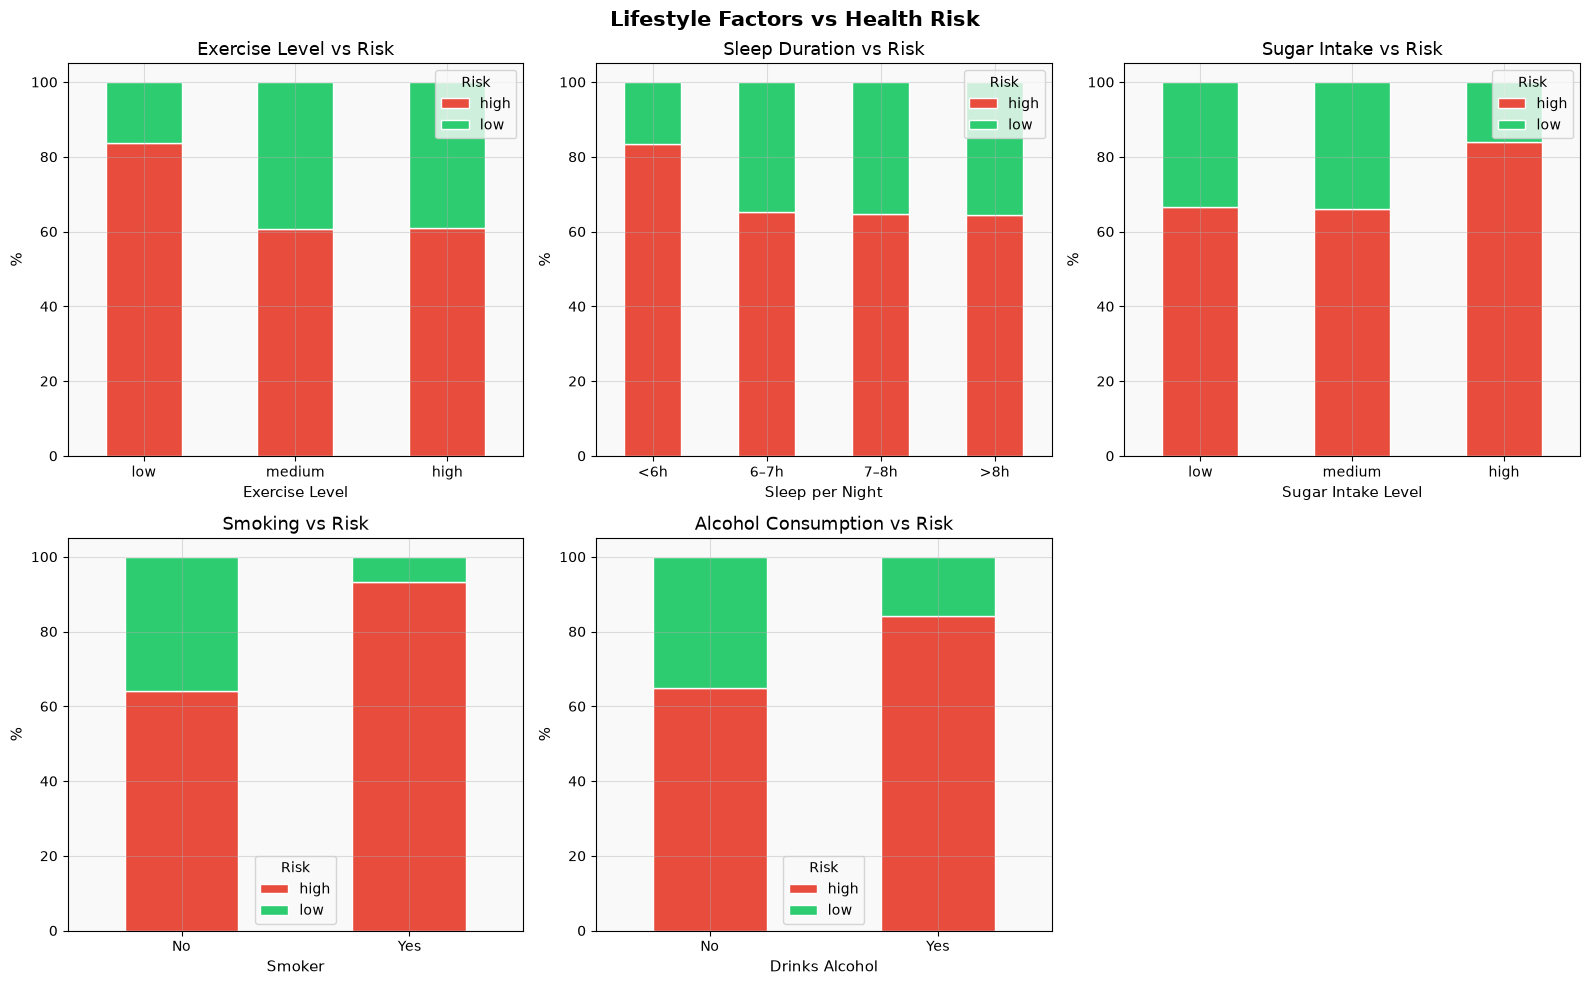

In [11]:
lifestyle_vars = ['exercise', 'sleep', 'sugar_intake', 'smoking', 'alcohol']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Lifestyle Factors vs Health Risk', fontsize=15, fontweight='bold')
axes = axes.flatten()

# ── Exercise ──
ex_order = ['low', 'medium', 'high']
ex_risk  = (df.groupby(['exercise', 'health_risk'])
              .size().unstack(fill_value=0)
              .reindex(ex_order))
ex_pct   = ex_risk.div(ex_risk.sum(axis=1), axis=0) * 100
ex_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
            edgecolor='white')
axes[0].set_title('Exercise Level vs Risk')
axes[0].set_xlabel('Exercise Level'); axes[0].set_ylabel('%')
axes[0].set_xticklabels(ex_order, rotation=0)
axes[0].legend(title='Risk')

# ── Sleep ──
sleep_bins   = [4, 6, 7, 8, 10]
sleep_labels = ['<6h', '6–7h', '7–8h', '>8h']
df['sleep_group'] = pd.cut(df['sleep'], bins=sleep_bins, labels=sleep_labels)
sl_risk = (df.groupby(['sleep_group', 'health_risk'], observed=True)
             .size().unstack(fill_value=0))
sl_pct  = sl_risk.div(sl_risk.sum(axis=1), axis=0) * 100
sl_pct.plot(kind='bar', stacked=True, ax=axes[1],
            color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
            edgecolor='white')
axes[1].set_title('Sleep Duration vs Risk')
axes[1].set_xlabel('Sleep per Night'); axes[1].set_ylabel('%')
axes[1].set_xticklabels(sleep_labels, rotation=0)
axes[1].legend(title='Risk')

# ── Sugar Intake ──
sg_order = ['low', 'medium', 'high']
sg_risk  = (df.groupby(['sugar_intake', 'health_risk'])
              .size().unstack(fill_value=0)
              .reindex(sg_order))
sg_pct   = sg_risk.div(sg_risk.sum(axis=1), axis=0) * 100
sg_pct.plot(kind='bar', stacked=True, ax=axes[2],
            color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
            edgecolor='white')
axes[2].set_title('Sugar Intake vs Risk')
axes[2].set_xlabel('Sugar Intake Level'); axes[2].set_ylabel('%')
axes[2].set_xticklabels(sg_order, rotation=0)
axes[2].legend(title='Risk')

# ── Smoking ──
sm_risk = (df.groupby(['smoking', 'health_risk'])
             .size().unstack(fill_value=0))
sm_pct  = sm_risk.div(sm_risk.sum(axis=1), axis=0) * 100
sm_pct.plot(kind='bar', stacked=True, ax=axes[3],
            color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
            edgecolor='white')
axes[3].set_title('Smoking vs Risk')
axes[3].set_xlabel('Smoker'); axes[3].set_ylabel('%')
axes[3].set_xticklabels(['No', 'Yes'], rotation=0)
axes[3].legend(title='Risk')

# ── Alcohol ──
al_risk = (df.groupby(['alcohol', 'health_risk'])
             .size().unstack(fill_value=0))
al_pct  = al_risk.div(al_risk.sum(axis=1), axis=0) * 100
al_pct.plot(kind='bar', stacked=True, ax=axes[4],
            color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
            edgecolor='white')
axes[4].set_title('Alcohol Consumption vs Risk')
axes[4].set_xlabel('Drinks Alcohol'); axes[4].set_ylabel('%')
axes[4].set_xticklabels(['No', 'Yes'], rotation=0)
axes[4].legend(title='Risk')

axes[5].axis('off')
plt.tight_layout()
plt.show()

**📌 Key Insights — Lifestyle Factors**

Across the five lifestyle dimensions, a clear pattern emerges:

- **Exercise** shows a step change rather than a gradient — low exercisers sit at ~84% high risk, while medium and high exercisers both drop to ~61%. The jump happens between low and medium, with little additional benefit from medium to high.
- **Sleep duration** shows a similar pattern — under 6 hours pushes risk to ~84%, while anything above 6 hours settles around 64–65%, regardless of whether it's 6–7h, 7–8h, or over 8h. The risk reduction comes from clearing the 6-hour threshold, not from sleeping more beyond it.
- **Smoking** produces the sharpest split of any factor — smokers sit at roughly 93% high risk versus ~64% for non-smokers, making it the single strongest individual signal in this set.
- **Alcohol consumption** also shows a meaningful gap — ~84% high risk for drinkers versus ~65% for non-drinkers, though smaller than smoking's effect.
- **Sugar intake** is the flattest relationship here — low and medium sugar intake both sit around 66–67% high risk, while high sugar intake jumps to ~84%. The effect only shows up at the high end.

The implication for wellness programs: **smoking cessation and alcohol reduction** show the largest individual swings in risk classification, while exercise and sleep interventions matter most for moving people past a specific threshold (sedentary → active, under 6h → over 6h) rather than maximizing time spent in the healthiest tier.

---
## 5. Risk by Profession

Profession acts as a proxy for lifestyle patterns — sedentary desk jobs, irregular schedules, physical labor, and access to healthcare all correlate with occupation. For an insurer, profession is also a directly observable attribute at onboarding.


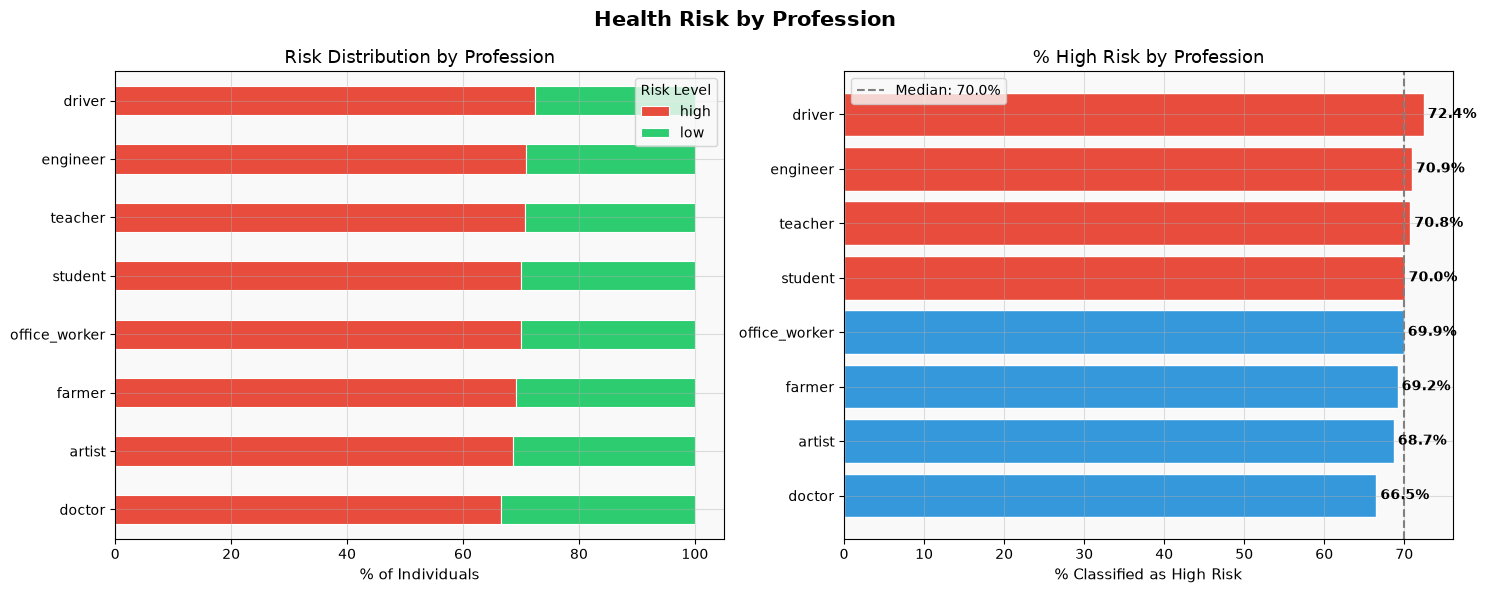


── High Risk % by Profession (sorted) ──
profession
driver           72.4
engineer         70.9
teacher          70.8
student          70.0
office_worker    69.9
farmer           69.2
artist           68.7
doctor           66.5


In [12]:
prof_risk = (df.groupby(['profession', 'health_risk'])
               .size().unstack(fill_value=0))
prof_risk_pct = prof_risk.div(prof_risk.sum(axis=1), axis=0) * 100

# Sort by high-risk %
if 'high' in prof_risk_pct.columns:
    prof_risk_pct = prof_risk_pct.sort_values('high', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Health Risk by Profession', fontsize=15, fontweight='bold')

# Horizontal stacked bar
prof_risk_pct.plot(kind='barh', stacked=True, ax=axes[0],
                   color=[RISK_PALETTE['high'], RISK_PALETTE['low']],
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('Risk Distribution by Profession')
axes[0].set_xlabel('% of Individuals')
axes[0].set_ylabel('')
axes[0].legend(title='Risk Level')

# High-risk % only — cleaner read
if 'high' in prof_risk_pct.columns:
    high_by_prof = prof_risk_pct['high']
    colors = [RISK_PALETTE['high'] if v >= high_by_prof.median() else ACCENT
              for v in high_by_prof.values]
    bars = axes[1].barh(high_by_prof.index, high_by_prof.values,
                        color=colors, edgecolor='white')
    axes[1].axvline(high_by_prof.median(), color='gray', linestyle='--',
                    linewidth=1.5, label=f'Median: {high_by_prof.median():.1f}%')
    axes[1].set_title('% High Risk by Profession')
    axes[1].set_xlabel('% Classified as High Risk')
    axes[1].legend()
    for bar, val in zip(bars, high_by_prof.values):
        axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n── High Risk % by Profession (sorted) ──")
if 'high' in prof_risk_pct.columns:
    print(prof_risk_pct['high'].sort_values(ascending=False).round(1).to_string())


**📌 Insight — Profession Risk Profiles**

Unlike lifestyle factors, profession doesn't separate risk groups sharply — every profession falls within a tight 66–72% high-risk band, clustered around the dataset's overall ~70% high-risk baseline. The spread from highest (driver, 72.4%) to lowest (doctor, 66.5%) is under 6 percentage points.

A few mild patterns are still visible:

- **Drivers** sit at the top (72.4%) — plausibly tied to irregular schedules and limited structured exercise, though the margin over other professions is small.
- **Doctors** sit at the bottom (66.5%) — the only profession to drop meaningfully below the 70% median, possibly reflecting higher health literacy or access to care.
- **Engineers, teachers, students, and office workers** all sit almost exactly at the median (69.9–70.9%), suggesting profession alone isn't doing much differentiating work for these groups.

**For the insurer:** profession is a much weaker segmentation lever than lifestyle behaviors like smoking or exercise. It's still useful as a mild prioritization signal (drivers first, doctors last), but wellness messaging will get far more leverage from targeting smoking/sleep/exercise patterns directly than from profession-based campaigns alone.

---
## 6. Compound Risk — Multi-Factor Burden

Single factors tell one story. The real signal for insurance risk is **how lifestyle burdens stack**. 
We construct a simple Lifestyle Risk Score by counting the number of adverse behaviors per individual.


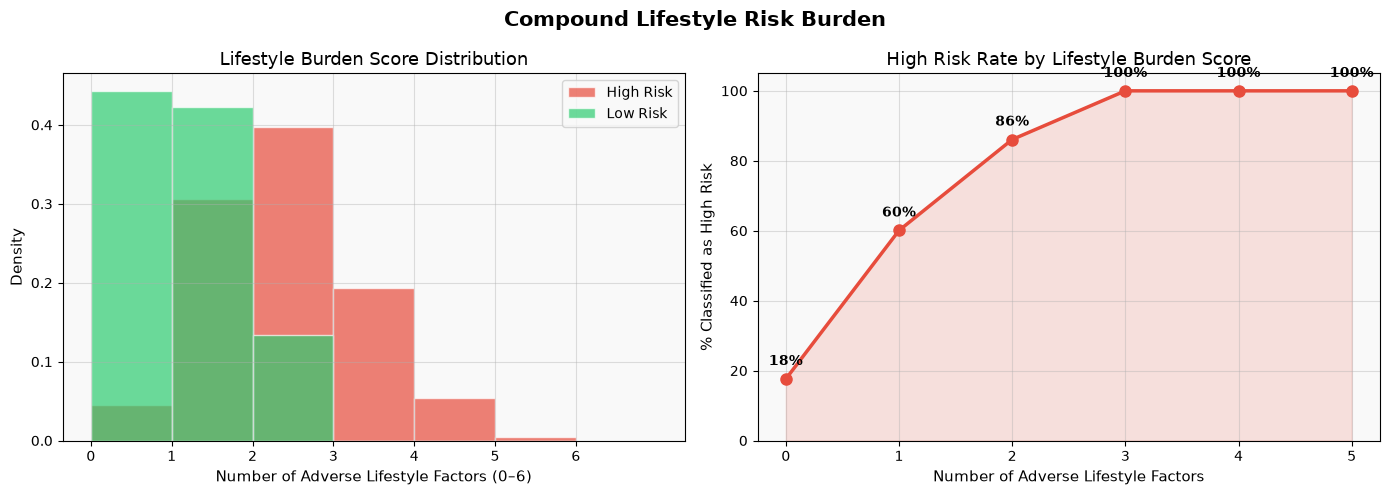


── High Risk % by Burden Score ──
risk_burden
0.0     17.6
1.0     60.1
2.0     86.1
3.0    100.0
4.0    100.0
5.0    100.0

Avg burden — High Risk : 1.92
Avg burden — Low Risk  : 0.69


In [13]:
# Encode exercise low = bad, high = good
ex_map  = {'low': 1, 'medium': 0, 'high': 0}
slp_bad = (df['sleep'] < 6).astype(int)
sg_map  = {'low': 0, 'medium': 0, 'high': 1}

df['risk_burden'] = (
    df['exercise'].map(ex_map) +
    slp_bad +
    df['sugar_intake'].map(sg_map) +
    (df['smoking']  == 'yes').astype(int) +
    (df['alcohol']  == 'yes').astype(int) +
    (df['bmi'] > 30).astype(int)
)

burden_risk = (df.groupby(['risk_burden', 'health_risk'])
                 .size().unstack(fill_value=0))
burden_pct  = burden_risk.div(burden_risk.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Compound Lifestyle Risk Burden', fontsize=15, fontweight='bold')

# Distribution of burden score
for risk, color in RISK_PALETTE.items():
    subset = df[df['health_risk'] == risk]['risk_burden']
    axes[0].hist(subset, bins=range(0, 8), alpha=0.7, color=color,
                 label=f'{risk.title()} Risk', edgecolor='white', density=True)
axes[0].set_xlabel('Number of Adverse Lifestyle Factors (0–6)')
axes[0].set_ylabel('Density')
axes[0].set_title('Lifestyle Burden Score Distribution')
axes[0].legend()
axes[0].set_xticks(range(7))

# High risk % by burden
if 'high' in burden_pct.columns:
    axes[1].plot(burden_pct.index, burden_pct['high'],
                 color=RISK_PALETTE['high'], marker='o',
                 linewidth=2.5, markersize=8)
    axes[1].fill_between(burden_pct.index, burden_pct['high'],
                         alpha=0.15, color=RISK_PALETTE['high'])
    axes[1].set_xlabel('Number of Adverse Lifestyle Factors')
    axes[1].set_ylabel('% Classified as High Risk')
    axes[1].set_title('High Risk Rate by Lifestyle Burden Score')
    axes[1].set_xticks(burden_pct.index)
    axes[1].set_ylim(0, 105)
    for x, y in zip(burden_pct.index, burden_pct['high'].values):
        axes[1].annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                         xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n── High Risk % by Burden Score ──")
if 'high' in burden_pct.columns:
    print(burden_pct['high'].round(1).to_string())
print(f"\nAvg burden — High Risk : {df[df['health_risk']=='high']['risk_burden'].mean():.2f}")
print(f"Avg burden — Low Risk  : {df[df['health_risk']=='low']['risk_burden'].mean():.2f}")


**📌 Insight — The Compounding Effect**

The risk burden score reveals a sharp, almost deterministic relationship with health risk:

- At **0 adverse factors**, only 17.6% are classified as high risk — this is the closest the dataset gets to a genuinely low-risk profile.
- Risk jumps immediately at **1 factor** (60.1%) and again at **2 factors** (86.1%) — the steepest part of the curve sits right here, between 0 and 2.
- At **3 or more adverse factors**, risk hits a flat 100% — every individual in this range is classified high risk, with zero exceptions through 4 and 5 factors.

The average burden score confirms the split: high-risk individuals carry **1.92 adverse factors on average**, versus just **0.69** for low-risk individuals — nearly a 3x difference.

The business implication is sharper than a gradual dose-response: **3 adverse factors functions as a hard ceiling**, not a soft threshold. A wellness program has its entire window for intervention between 0 and 2 factors — once someone crosses into 3, the data shows no recovery back to low-risk classification within this dataset. Onboarding screening that flags individuals sitting at 1–2 factors is the highest-leverage moment to act, before they cross into the saturated zone.

---
## 7. Correlation Analysis — Numeric Features

We examine how numeric features relate to each other and to health risk.


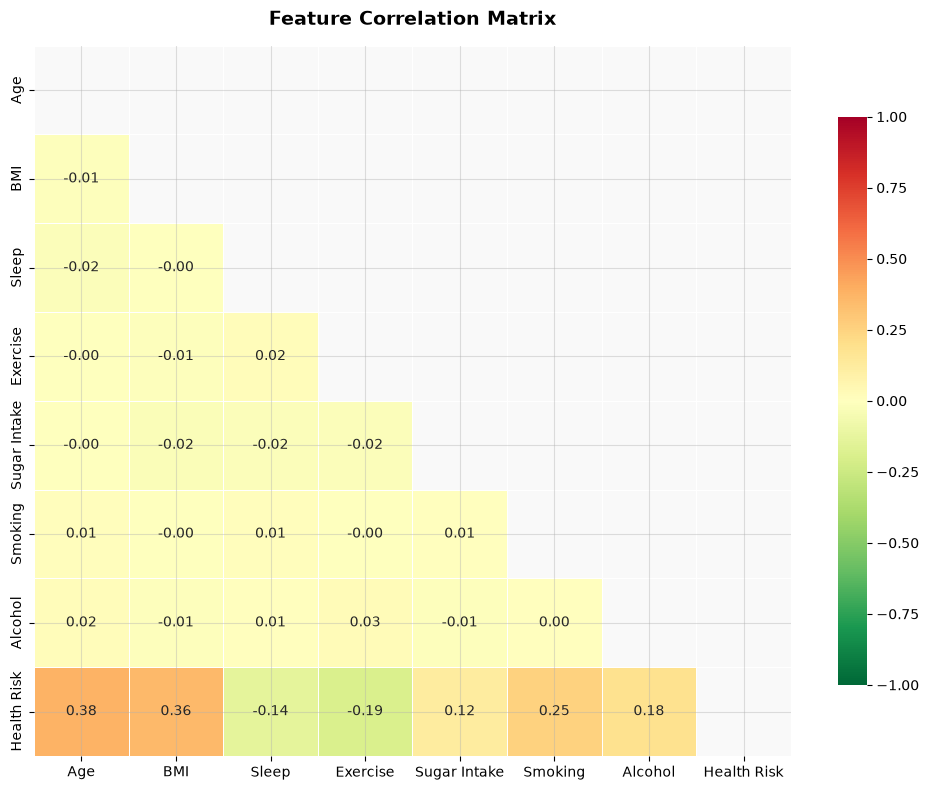


── Correlation with Health Risk (sorted) ──
Age             0.380
BMI             0.359
Smoking         0.253
Exercise       -0.188
Alcohol         0.181
Sleep          -0.138
Sugar Intake    0.119


In [14]:
# Encode for correlation
df_enc = df.copy()
df_enc['health_risk_bin'] = (df_enc['health_risk'] == 'high').astype(int)
df_enc['exercise_enc']    = df_enc['exercise'].map({'low': 0, 'medium': 1, 'high': 2})
df_enc['sugar_enc']       = df_enc['sugar_intake'].map({'low': 0, 'medium': 1, 'high': 2})
df_enc['smoking_enc']     = (df_enc['smoking'] == 'yes').astype(int)
df_enc['alcohol_enc']     = (df_enc['alcohol'] == 'yes').astype(int)

corr_cols = ['age', 'bmi', 'sleep', 'exercise_enc', 'sugar_enc',
             'smoking_enc', 'alcohol_enc', 'health_risk_bin']
corr_labels = ['Age', 'BMI', 'Sleep', 'Exercise', 'Sugar Intake',
               'Smoking', 'Alcohol', 'Health Risk']

corr_matrix = df_enc[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlates with health risk
corr_with_target = corr_matrix['Health Risk'].drop('Health Risk').sort_values(key=abs, ascending=False)
print("\n── Correlation with Health Risk (sorted) ──")
print(corr_with_target.round(3).to_string())


---
## 8. Segment Heatmap — Profession × Age Group

Combining two categorical dimensions gives us a risk map across naturally occurring customer segments — 
the kind of view an insurance analyst would use to prioritize outreach.


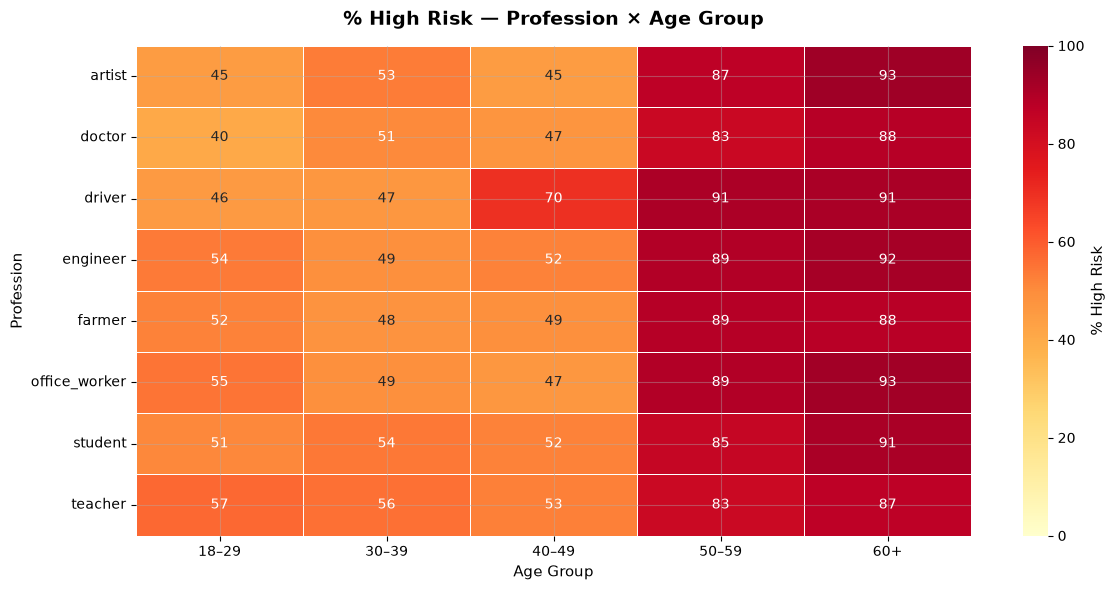

In [15]:
pivot = df.pivot_table(index='profession', columns='age_group',
                       values='health_risk',
                       aggfunc=lambda x: (x == 'high').mean() * 100,
                       observed=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% High Risk'},
            ax=ax, vmin=0, vmax=100)
ax.set_title('% High Risk — Profession × Age Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group'); ax.set_ylabel('Profession')
plt.tight_layout()
plt.show()


**📌 Insight — Segment Risk Map**

The dominant pattern in this heatmap isn't profession — it's age. Every profession shows a near-identical shape: risk sits in the 40–57% range for 18–49, then jumps sharply to 83–93% for 50+. The 30-point jump between the 40–49 and 50–59 columns is far larger than any variation across professions within a single age band.

A few specific points worth calling out:

- **Drivers aged 40–49** are the one clear exception to the otherwise flat under-50 pattern, sitting at 70% — meaningfully higher than every other profession in that age band.
- **60+ individuals** are uniformly high risk regardless of profession (87–93%), with office workers and artists topping out at 93%.
- **Under-50 risk is remarkably profession-agnostic** — teachers, engineers, and students in the 18–29 to 40–49 range all cluster within a tight 45–57% band, suggesting age is doing almost all the work here, not occupation.

This reframes the earlier profession-only finding: profession barely matters as a standalone signal, but **age crossing 50 is the single sharpest dividing line in the entire dataset**. For the insurer, this means onboarding risk screening should weight age far more heavily than occupation, with the driver/40–49 segment flagged as a notable outlier worth investigating further — it may reflect an occupational hazard (irregular hours, road risk exposure) that compounds earlier than for other professions.

---
## 9. Key Findings & Business Recommendations

### Summary of Findings

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | 69.8% of the customer base is classified as high risk — high risk is the norm, not the exception | Claims exposure is broad-based, not concentrated in a small subgroup |
| 2 | Smoking produces the sharpest single split (93% vs 64% high risk) | Smoking cessation is the highest-leverage individual intervention available |
| 3 | Exercise and sleep show threshold effects, not gradients — risk drops once you clear "low exercise" or "under 6h sleep," with little extra benefit beyond that | Programs should focus on moving people past the threshold, not maximizing time in the best tier |
| 4 | Risk burden score is a near-deterministic predictor — 0 factors = 17.6% high risk, 3+ factors = 100% high risk, no exceptions | 3 adverse factors functions as a hard ceiling; the entire intervention window is between 0–2 factors |
| 5 | Profession is a weak standalone signal — every profession sits within a tight 66–72% band | Profession-based campaigns will underperform compared to targeting lifestyle behaviors directly |
| 6 | Age is the dominant segmentation variable — every profession jumps from ~45–57% high risk (under 50) to 83–93% (50+) | Age 50 is the sharpest dividing line in the dataset; risk screening should weight it heavily |
| 7 | Drivers aged 40–49 are a notable outlier (70% vs ~45–55% for other professions at that age) | Worth flagging as a specific occupational risk pattern for targeted investigation |

---

### Recommended Actions

**1. Lead with Smoking and Alcohol, Not Profession**  
Smoking (93% vs 64%) and alcohol (84% vs 65%) produce far larger risk splits than any profession-based grouping. Wellness budget should prioritize cessation and moderation programs over occupation-specific campaigns.

**2. Build the Risk Burden Score into Onboarding**  
Since 3+ adverse factors maps to 100% high-risk classification with no exceptions, a simple count of adverse behaviors (low/no exercise, <6h sleep, high sugar, smoking, drinking, high BMI) at onboarding can flag the highest-priority individuals immediately, before claims accumulate.

**3. Weight Age Heavily in Risk Screening**  
The jump from under-50 to 50+ is the single largest jump in the entire dataset — far larger than any profession or even most individual lifestyle factors. Premium tiering and proactive outreach should treat the 50+ threshold as a primary signal.

**4. Target the Threshold, Not the Ceiling**  
Exercise and sleep don't reward "more is better" — they reward clearing a line (sedentary → active, under 6h → over 6h). Messaging and incentive design should focus on getting people across that line rather than pushing already-active, well-rested individuals further.

**5. Investigate the Driver 40–49 Outlier**  
This segment breaks the otherwise consistent under-50 pattern across professions and may point to an occupational hazard (irregular hours, sustained driving stress) worth a closer, separate analysis.

---

In [16]:
# ── Project Summary ──
print("="*60)
print("  LIFESTYLE HEALTH RISK — EDA COMPLETE")
print("="*60)
print(f"  Dataset     : 5,000 individuals, 12 features")
print(f"  High Risk   : {(df['health_risk']=='high').sum():,} ({(df['health_risk']=='high').mean()*100:.1f}%)")
print(f"  Low Risk    : {(df['health_risk']=='low').sum():,}  ({(df['health_risk']=='low').mean()*100:.1f}%)")
print()
print("  Key risk factors identified:")
print("    ✔ Low exercise")
print("    ✔ Smoking")  
print("    ✔ Sleep < 6 hours")
print("    ✔ High BMI (obese category)")
print("    ✔ High sugar intake")
print("    ✔ Age 60+")
print()
print("  Next: SQL Analysis → Power BI Dashboard")
print("="*60)


  LIFESTYLE HEALTH RISK — EDA COMPLETE
  Dataset     : 5,000 individuals, 12 features
  High Risk   : 3,490 (69.8%)
  Low Risk    : 1,510  (30.2%)

  Key risk factors identified:
    ✔ Low exercise
    ✔ Smoking
    ✔ Sleep < 6 hours
    ✔ High BMI (obese category)
    ✔ High sugar intake
    ✔ Age 60+

  Next: SQL Analysis → Power BI Dashboard
